Import Model Configuration
==========================

In [1]:
import yaml

model_cfg = "maskrcnn_resnet50_fpn_v2.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'maskrcnn_resnet50_fpn_v2'

Dataset Class
=============

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None, subset_fraction=1.0):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        all_ids = list(self.coco.imgs.keys())

        # Use only a fraction of the dataset
        subset_len = int(len(all_ids) * subset_fraction)
        self.ids = all_ids[:subset_len]

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann:
                continue

            rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
            mask = coco_mask.decode(rles)
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

            # ⚠️ Filter out zero-area boxes *after transforms*
            boxes = target["boxes"]
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])

            # Apply keep mask to all fields
            target["boxes"] = tv_tensors.BoundingBoxes(boxes[keep], format="XYXY", canvas_size=img.shape[-2:])
            target["labels"] = target["labels"][keep]
            if "masks" in target:
                target["masks"] = target["masks"][keep]
            if "area" in target:
                target["area"] = target["area"][keep]
            if "iscrowd" in target:
                target["iscrowd"] = target["iscrowd"][keep]

        return img, target

    def __len__(self):
        return len(self.ids)


Augmentiations
=============

In [3]:
from torchvision.transforms import v2 as T
import torch

def get_transform(train: bool):

    model_name = cfg['model']
    is_unet = "unet" in model_name

    if is_unet:
        if train:
            transforms = [
                T.Resize((512, 512)),
                T.RandomHorizontalFlip(p=0.5),
            ]
        else:
            transforms = [T.Resize((512, 512))]

        transforms += [
            T.ToDtype(torch.float32, scale=True),
            T.ToPureTensor(),
        ]

        return T.Compose(transforms)
    
    else:
        if train:
            transforms = [
                T.RandomPhotometricDistort(),  # Color jitter
                T.Resize((512, 512)),          # Fixed resize for stability
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(degrees=10, fill=0, expand=False),  # Limit rotation area
                # T.RandomZoomOut(fill=0, p=0.3),  # Optional — leave off for now
                # T.RandomCrop((512, 512), pad_if_needed=False, fill=0),  # Only if images are bigger
            ]
        else:
            transforms = [
                T.Resize((512, 512)),                                   # Consistent resize for val/test
            ]

        transforms += [
            T.ToDtype(torch.float32, scale=True),                       # Convert image to float32 in [0, 1]
            T.ToPureTensor(),                                           # Convert to torch.Tensor (Image, Mask, BBoxes)
        ]

        return T.Compose(transforms)

Log Hyperparams to TensorBoard
===============================

In [4]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import shutil, os

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

log_dir = f"runs/{cfg['experiment_name']}_{timestamp}"

if os.path.exists(log_dir):
    shutil.rmtree(log_dir)

# Save cfg as hyperparameters (flatten dictionary)
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

writer = SummaryWriter(log_dir=f"runs/{cfg['experiment_name']}_{timestamp}")

# Option 1: Save flattened cfg to TensorBoard as hparams
flattened_cfg = flatten_dict(cfg)

# Option 2: Also log as text (for easier reading)
cfg_text = yaml.dump(cfg, sort_keys=False)
writer.add_text("config", f"```yaml\n{cfg_text}\n```")


Dice
====

In [5]:
def compute_dice(preds, targets, num_classes, smooth=1e-6):
    """
    Computes mean Dice score over all foreground classes (excludes background class 0).
    
    preds: [B, H, W] — predicted class indices
    targets: [B, H, W] — ground truth class indices
    """
    dice = 0.0
    valid_classes = 0

    for cls in range(1, num_classes):  # skip background
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        if target_cls.sum() == 0 and pred_cls.sum() == 0:
            continue  # skip if class is absent in both pred and target (avoids misleading boost)

        intersection = (pred_cls * target_cls).sum(dim=(1, 2))
        union = pred_cls.sum(dim=(1, 2)) + target_cls.sum(dim=(1, 2))

        dice_cls = (2.0 * intersection + smooth) / (union + smooth)
        dice += dice_cls.mean()
        valid_classes += 1

    return dice / valid_classes if valid_classes > 0 else torch.tensor(0.0)


Initialization
=============

In [6]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate

from tqdm import tqdm
import sys
import time

from models import MODEL_REGISTRY



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

s_fraction = 1

# COCO-style dataset using your structure
dataset = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/train",
    transforms=get_transform(train=True),
    subset_fraction=s_fraction
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/valid",
    transforms=get_transform(train=False),
    subset_fraction=s_fraction
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/test",
    transforms=get_transform(train=False),
    subset_fraction=s_fraction
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dynamically assign number of workers
n_workers = 4 if torch.cuda.is_available() else 0

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

# Two classes: background + foreground
num_classes = cfg['num_classes']

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
#model = get_model_instance_segmentation(num_classes)

model.to(device)

loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Train size: 1049
Validation size: 300
Test size: 150


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

Train
=====

In [7]:
import csv

# Optimizer and LR scheduler from config
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=cfg["train"]["lr"],
    momentum=cfg["train"]["momentum"],
    weight_decay=cfg["train"]["weight_decay"],
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg["train"]["lr_step_size"],
    gamma=cfg["train"]["gamma"],
)


num_epochs = cfg['train']['epochs']
print("Start training...")

#scaler = torch.cuda.amp.GradScaler()  # Enable AMP if you want (optional)
scaler = torch.amp.GradScaler()  # Updated for modern AMP


cfg["output_dir"] = f"outputs/{cfg['experiment_name']}_{timestamp}"
os.makedirs(cfg["output_dir"], exist_ok=True)

best_val = -float("inf")
patience = 5  # Number of epochs to wait for improvement
epochs_no_improve = 0
best_epoch = -1

best_segm_stats = None  # To store best stats row

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    sys.stdout.flush()

    start_time = time.time()

    # tqdm-wrapped version of the training loop
    model.train()
    metric_logger = utils.MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", utils.SmoothedValue(window_size=1, fmt="{value:.6f}"))

    header = f"Epoch: [{epoch}]"

    # Optional warmup scheduler for the first epoch
    warmup_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for batch_idx, (images, targets) in enumerate(tqdm(data_loader, desc=header)):
        images = list(img.to(device) for img in images)
        #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Mixed precision (optional)
        #with torch.cuda.amp.autocast(enabled=False):  # Set to True to enable AMP
        with torch.amp.autocast(device_type='cuda', enabled=False):  # Set to True to enable AMP
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # Check for NaN or inf loss
        if not torch.isfinite(losses):
            print(f"[!] Loss is {losses.item()}, stopping training")
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        # AMP (uncomment if you enable autocast)
        # scaler.scale(losses).backward()
        # scaler.step(optimizer)
        # scaler.update()

        losses.backward()
        optimizer.step()

        if warmup_scheduler is not None:
            warmup_scheduler.step()

        # Safely remove duplicate 'loss' to avoid clash
        loss_dict_clean = {k: v for k, v in loss_dict.items() if k != "loss"}

        # Log total loss and the rest of loss_dict
        metric_logger.update(loss=losses.item(), **{k: v.item() for k, v in loss_dict_clean.items()})

        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

        # Log to TensorBoard
        global_step = epoch * len(data_loader) + batch_idx
        writer.add_scalar("Train/Loss", losses.item(), global_step)
        writer.add_scalar("Train/LR", optimizer.param_groups[0]["lr"], global_step)

    lr_scheduler.step()
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} completed in {epoch_time:.2f} seconds.")
    


    # Validation
    from torchmetrics import JaccardIndex, Accuracy

    # Determine model type for evaluation logic
    model_name = cfg['model']
    is_unet = "unet" in model_name

    # Validation
    print("Evaluating on validation set:")

    if is_unet:
        model.eval()

        miou = JaccardIndex(num_classes=num_classes, average='macro', task='multiclass').to(device)
        acc = Accuracy(num_classes=num_classes, average='macro', task='multiclass').to(device)

        all_preds = []
        all_targets = []

        with torch.no_grad():
            for images, targets in data_loader_valid:
                images = images.to(device) if isinstance(images, torch.Tensor) else torch.stack(images).to(device)
                target_masks = torch.stack([
                    t["masks"].sum(dim=0).clamp(0, 1).long()
                    for t in targets
                ]).to(device)

                outputs = model(images)
                # Convert list of dicts to tensor of preds
                preds = torch.stack([ r["masks"].squeeze(0) for r in outputs ]).to(device)  # ensure preds on correct device

                # Match target size to prediction (if needed)
                if preds.shape[-2:] != target_masks.shape[-2:]:
                    target_masks = F.interpolate(
                        target_masks.unsqueeze(1).float(), size=preds.shape[-2:], mode='nearest'
                    ).squeeze(1).long()

                # Accumulate for Dice computation
                all_preds.append(preds)
                all_targets.append(target_masks)

                # Update metrics
                miou.update(preds, target_masks)
                acc.update(preds, target_masks)

        # Stack all for Dice
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        dice_score = compute_dice(all_preds, all_targets, num_classes)

        # Final metric computation
        miou = miou.compute().item()
        pixel_acc = acc.compute().item()

        print(f"Validation mIoU: {miou:.4f}, Pixel Accuracy: {pixel_acc:.4f}, Dice Score: {dice_score:.4f}")

        writer.add_scalar("Val/mIoU", miou, epoch)
        writer.add_scalar("Val/Pixel_Acc", pixel_acc, epoch)
        writer.add_scalar("Val/Dice", dice_score, epoch)

        current_val = miou  # Or dice_score if that's your validation criterion

        # Save to CSV
        csv_path = os.path.join(cfg["output_dir"], "segm_metrics.csv")
        if epoch == 0 and not os.path.exists(csv_path):
            with open(csv_path, mode='w', newline='') as f:
                csv_writer = csv.writer(f)
                csv_writer.writerow([
                    "epoch", "mIoU", "Pixel_Accuracy", "Dice_Score"
                ])

        with open(csv_path, mode='a', newline='') as f:
            csv_writer = csv.writer(f)
            csv_writer.writerow([epoch, miou, pixel_acc, dice_score])


    else:
        coco_evaluator = evaluate(model, data_loader_valid, device=device)

        # Extract segmentation (IoU type: 'segm') metrics
        segm_eval = coco_evaluator.coco_eval["segm"]
        segm_stats = segm_eval.stats  # List of 12 standard COCO segmentation metrics

        # Save to CSV
        csv_path = os.path.join(cfg["output_dir"], "segm_metrics.csv")
        if epoch == 0 and not os.path.exists(csv_path):
            with open(csv_path, mode='w', newline='') as f:
                csv_writer = csv.writer(f)
                csv_writer.writerow([
                    "epoch", "AP@[IoU=0.50:0.95]", "AP@0.50", "AP@0.75", "AP_small",
                    "AP_medium", "AP_large", "AR@max=1", "AR@max=10", "AR@max=100",
                    "AR_small", "AR_medium", "AR_large"
                ])
        with open(csv_path, mode='a', newline='') as f:
            csv_writer = csv.writer(f)
            csv_writer.writerow([epoch] + list(segm_stats))

        # Log to TensorBoard
        writer.add_scalar("Val/segm_mAP", segm_stats[0], epoch)
        writer.add_scalar("Val/segm_mAP_50", segm_stats[1], epoch)
        writer.add_scalar("Val/segm_mAP_75", segm_stats[2], epoch)
        writer.add_scalar("Val/segm_mAP_small", segm_stats[3], epoch)
        writer.add_scalar("Val/segm_mAP_medium", segm_stats[4], epoch)
        writer.add_scalar("Val/segm_mAP_large", segm_stats[5], epoch)
        writer.add_scalar("Val/segm_AR_max1", segm_stats[6], epoch)
        writer.add_scalar("Val/segm_AR_max10", segm_stats[7], epoch)
        writer.add_scalar("Val/segm_AR_max100", segm_stats[8], epoch)
        writer.add_scalar("Val/segm_AR_small", segm_stats[9], epoch)
        writer.add_scalar("Val/segm_AR_medium", segm_stats[10], epoch)
        writer.add_scalar("Val/segm_AR_large", segm_stats[11], epoch)

        current_val = segm_stats[0]  # mAP

    # Create output directory if it doesn't exist
    os.makedirs(cfg["output_dir"], exist_ok=True)

    if current_val > best_val:  # For mAP, higher is better

        print(f"Current val {current_val} higher than best val {best_val}.")
        best_val = current_val
        best_epoch = epoch + 1  # Save 1-based epoch
        
        if is_unet:
            best_segm_stats = (miou, pixel_acc, dice_score)
        else:
            best_segm_stats = segm_stats.copy()

        epochs_no_improve = 0  # Reset counter

        # Save model weights
        print(f"Saving model and checkpoint...")
        torch.save(model.state_dict(), os.path.join(cfg["output_dir"], "model_best.pth"))

        # Optionally: save full checkpoint (model + optimizer + scheduler + epoch)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'lr_scheduler_state_dict': lr_scheduler.state_dict(),
        }, os.path.join(cfg["output_dir"], "checkpoint_best.pth"))
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}. Best metric was at epoch {best_epoch}.")
            break

# Save best epoch + stats to CSV
os.makedirs(cfg["output_dir"], exist_ok=True)

if is_unet:
    csv_path = os.path.join(cfg["output_dir"], "segm_metrics.csv")
    with open(csv_path, mode='w', newline='') as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow(["Best epoch", "mIoU", "Pixel Acc", "Dice Score"])
        csv_writer.writerow([best_epoch] + list(best_segm_stats))
else:
    csv_path = os.path.join(cfg["output_dir"], "segm_metrics.csv")
    with open(csv_path, mode='a', newline='') as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow([])
        csv_writer.writerow([f"Best epoch: {best_epoch}"])
        csv_writer.writerow([
            "epoch", "AP@[IoU=0.50:0.95]", "AP@0.50", "AP@0.75", "AP_small",
            "AP_medium", "AP_large", "AR@max=1", "AR@max=10", "AR@max=100",
            "AR_small", "AR_medium", "AR_large"
        ])
        csv_writer.writerow([best_epoch] + list(best_segm_stats))


print("\nThat's it!")

Start training...

Epoch 1/20


Epoch: [0]:   0%|          | 0/525 [00:00<?, ?it/s]

Epoch: [0]: 100%|██████████| 525/525 [07:59<00:00,  1.10it/s]


Epoch 1 completed in 479.14 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:38  model_time: 0.4229 (0.4229)  evaluator_time: 0.0087 (0.0087)  time: 0.5289  data: 0.0938  max mem: 3820
Test:  [100/300]  eta: 0:00:47  model_time: 0.2060 (0.2131)  evaluator_time: 0.0112 (0.0171)  time: 0.2400  data: 0.0041  max mem: 3820
Test:  [200/300]  eta: 0:00:23  model_time: 0.1978 (0.2118)  evaluator_time: 0.0066 (0.0183)  time: 0.2337  data: 0.0041  max mem: 3820
Test:  [299/300]  eta: 0:00:00  model_time: 0.2129 (0.2141)  evaluator_time: 0.0111 (0.0184)  time: 0.2345  data: 0.0059  max mem: 3820
Test: Total time: 0:01:11 (0.2390 s / it)
Averaged stats: model_time: 0.2129 (0.2141)  evaluator_time: 0.0111 (0.0184)
Accumulating evaluation results...
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.10s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.836
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [1]: 100%|██████████| 525/525 [07:32<00:00,  1.16it/s]


...

Epoch 8 completed in 414.03 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:01  model_time: 0.4734 (0.4734)  evaluator_time: 0.0100 (0.0100)  time: 0.6037  data: 0.1171  max mem: 3820
Test:  [100/300]  eta: 0:00:42  model_time: 0.1826 (0.1920)  evaluator_time: 0.0101 (0.0151)  time: 0.2136  data: 0.0038  max mem: 3820
Test:  [200/300]  eta: 0:00:21  model_time: 0.1762 (0.1917)  evaluator_time: 0.0053 (0.0166)  time: 0.2105  data: 0.0038  max mem: 3820
Test:  [299/300]  eta: 0:00:00  model_time: 0.2106 (0.1937)  evaluator_time: 0.0091 (0.0159)  time: 0.2417  data: 0.0075  max mem: 3820
Test: Total time: 0:01:04 (0.2156 s / it)
Averaged stats: model_time: 0.2106 (0.1937)  evaluator_time: 0.0091 (0.0159)
Accumulating evaluation results...
DONE (t=0.07s).
Accumulating evaluation results...
DONE (t=0.08s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.853
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [8]: 100%|██████████| 525/525 [07:38<00:00,  1.14it/s]


Epoch 9 completed in 458.83 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:10  model_time: 0.4594 (0.4594)  evaluator_time: 0.0125 (0.0125)  time: 0.6338  data: 0.1585  max mem: 3832
Test:  [100/300]  eta: 0:00:52  model_time: 0.2269 (0.2367)  evaluator_time: 0.0113 (0.0191)  time: 0.2611  data: 0.0045  max mem: 3832
Test:  [200/300]  eta: 0:00:26  model_time: 0.2130 (0.2362)  evaluator_time: 0.0088 (0.0201)  time: 0.2608  data: 0.0049  max mem: 3832
Test:  [299/300]  eta: 0:00:00  model_time: 0.1976 (0.2271)  evaluator_time: 0.0065 (0.0186)  time: 0.2119  data: 0.0039  max mem: 3832
Test: Total time: 0:01:15 (0.2525 s / it)
Averaged stats: model_time: 0.1976 (0.2271)  evaluator_time: 0.0065 (0.0186)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.06s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.865
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [9]: 100%|██████████| 525/525 [08:00<00:00,  1.09it/s]


Epoch 10 completed in 480.02 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:48  model_time: 0.4122 (0.4122)  evaluator_time: 0.0110 (0.0110)  time: 0.5628  data: 0.1351  max mem: 3832
Test:  [100/300]  eta: 0:00:49  model_time: 0.1996 (0.2240)  evaluator_time: 0.0108 (0.0157)  time: 0.2304  data: 0.0041  max mem: 3832
Test:  [200/300]  eta: 0:00:24  model_time: 0.1913 (0.2242)  evaluator_time: 0.0051 (0.0173)  time: 0.2318  data: 0.0040  max mem: 3832
Test:  [299/300]  eta: 0:00:00  model_time: 0.1950 (0.2224)  evaluator_time: 0.0059 (0.0162)  time: 0.2127  data: 0.0038  max mem: 3832
Test: Total time: 0:01:13 (0.2446 s / it)
Averaged stats: model_time: 0.1950 (0.2224)  evaluator_time: 0.0059 (0.0162)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.850
 Average Precision  (AP) @[ IoU=0.50 

In [8]:
# === Log hyperparameters and final validation metric ===
from torch.utils.tensorboard import SummaryWriter

flattened_cfg = flatten_dict(cfg)

if is_unet:
    writer.add_hparams(
        hparam_dict=flattened_cfg,
        metric_dict={"Val/best_mIoU": best_val}
    )
else:
    writer.add_hparams(
        hparam_dict=flattened_cfg,
        metric_dict={"Val/best_mAP": best_val}
    )

writer.close()

Test (Example)
=====

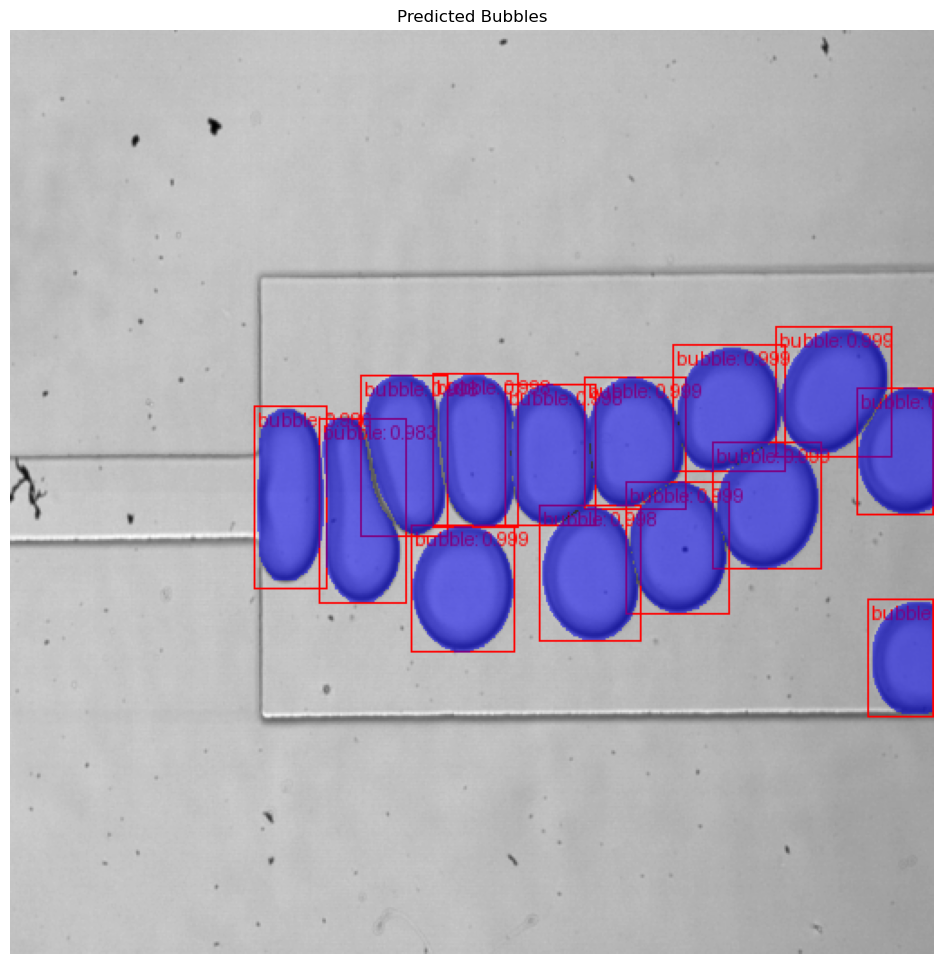

In [9]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torch

#image = read_image("../../../BubANN_GAN.v1i.coco-segmentation/test/BubGAN_0002_jpg.rf.a78f79c439aaf0c4cfcaac4ce751a071.jpg")
#image = read_image("../../../frames_ana\\02_07_20\\qc2_qd1_10x_formacao\\qc2_qd1_10x_formacao_00000.jpg")
#image = read_image("../../../frames_ana/02_07_20/qc2_qd1_10x_formacao2/qc2_qd1_10x_formacao2_00000.jpg")
image = read_image("../../../datasets/frames_ana/02_07_20/qc2_qd1_10x_formacao2/qc2_qd1_10x_formacao2_00000.jpg")
eval_transform = get_transform(train=False)

score_thresh = 0.9  # Confidence threshold
min_area = 500     # Minimum bubble size in pixels

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to(device)

    predictions = model([x])
    pred = predictions[0]

# Filter predictions by score
keep = pred["scores"] > score_thresh
scores = pred["scores"][keep]
boxes = pred["boxes"][keep]
masks = pred["masks"][keep]

# Filter masks by area (size)
areas = masks.sum(dim=[1, 2, 3])  # Sum over HxW for each mask
keep_area = areas > min_area

# Final filtered outputs
boxes = boxes[keep_area].cpu().long()
masks = (masks[keep_area].cpu() > 0.7).squeeze(1)
labels = [f"bubble: {score:.3f}" for score in scores[keep_area]]

# Prepare image for visualization (use x)
vis_img = (255.0 * (x.cpu() - x.cpu().min()) / (x.cpu().max() - x.cpu().min())).to(torch.uint8)
vis_img = vis_img[:3, ...]

#pred_labels = [f"bubble: {score:.3f}" for score in pred["scores"]]
#pred_boxes = pred["boxes"].cpu().long()
#masks = (pred["masks"].cpu() > 0.7).squeeze(1)

output_image = draw_bounding_boxes(vis_img, boxes, labels, colors="red")
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")
plt.title("Predicted Bubbles")
plt.show()

Resume Training from Checkpoint (Example)
==========================================

In [10]:
'''
checkpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']

or

checkpoint = torch.load("checkpoint_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']
'''

'\ncheckpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")\nmodel.load_state_dict(checkpoint[\'model_state_dict\'])\noptimizer.load_state_dict(checkpoint[\'optimizer_state_dict\'])\nlr_scheduler.load_state_dict(checkpoint[\'lr_scheduler_state_dict\'])\nstart_epoch = checkpoint[\'epoch\']\n\nor\n\ncheckpoint = torch.load("checkpoint_best.pth")\nmodel.load_state_dict(checkpoint[\'model_state_dict\'])\noptimizer.load_state_dict(checkpoint[\'optimizer_state_dict\'])\nlr_scheduler.load_state_dict(checkpoint[\'lr_scheduler_state_dict\'])\nstart_epoch = checkpoint[\'epoch\']\n'

Test Batch
=========

Image 0
Precision: 0.9673034882615721
Recall: 0.9836651846124106
F1: 0.9754157281832558
Intersection: 10177
Union: 10690
Dice: 0.9754157281365115
Drawing predictions...


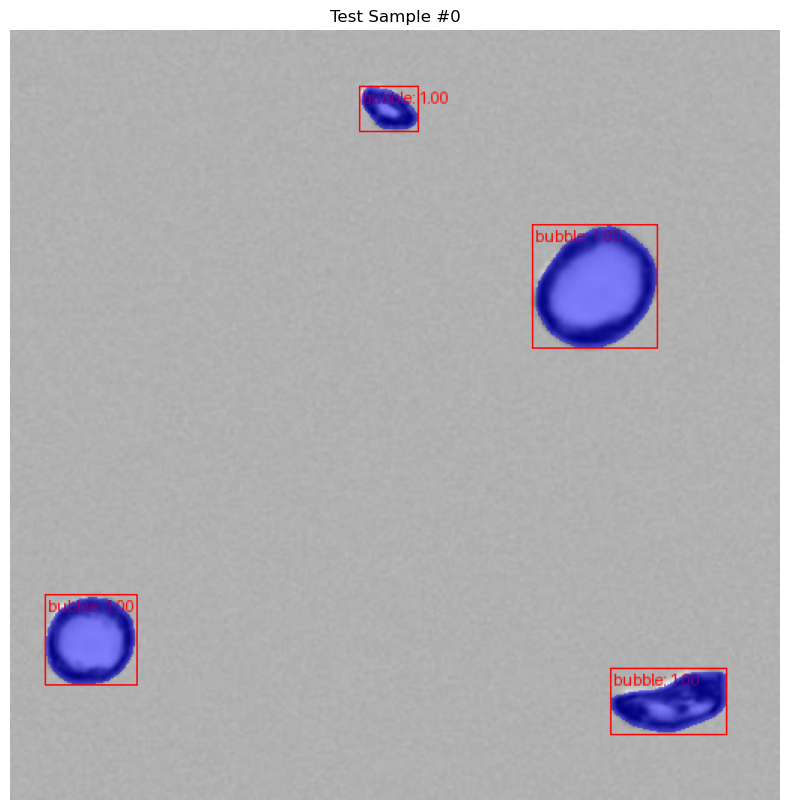

Image 1
Precision: 0.9966485331260929
Recall: 0.9201345291479821
F1: 0.9568643909718336
Intersection: 20519
Union: 22369
Dice: 0.9568643909495228
Drawing predictions...


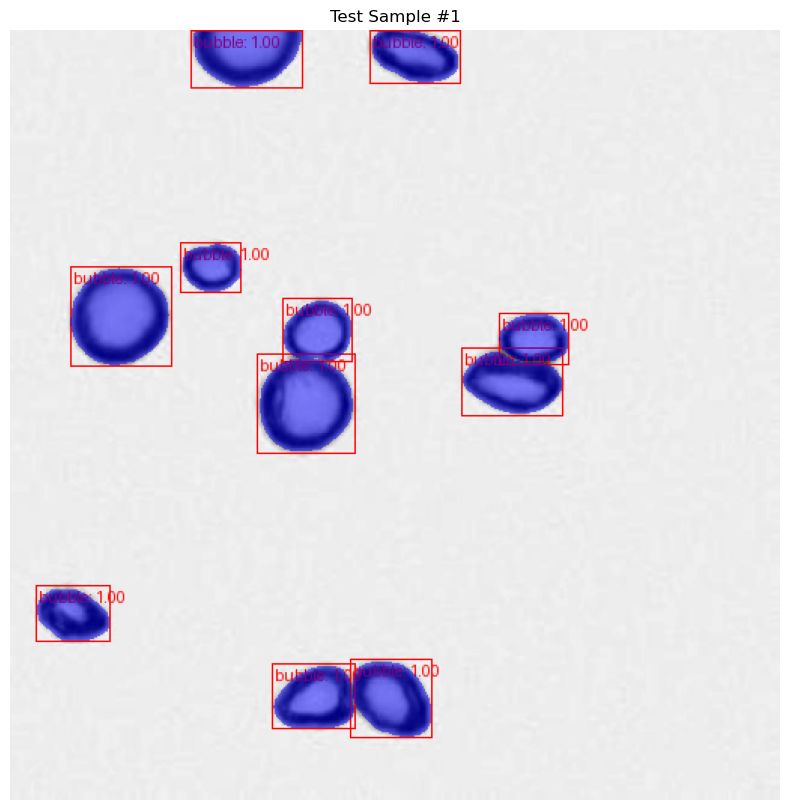

Image 2
Precision: 1.0
Recall: 0.8913782390994481
F1: 0.9425700483091788
Intersection: 24389
Union: 27361
Dice: 0.9425700482909648
Drawing predictions...


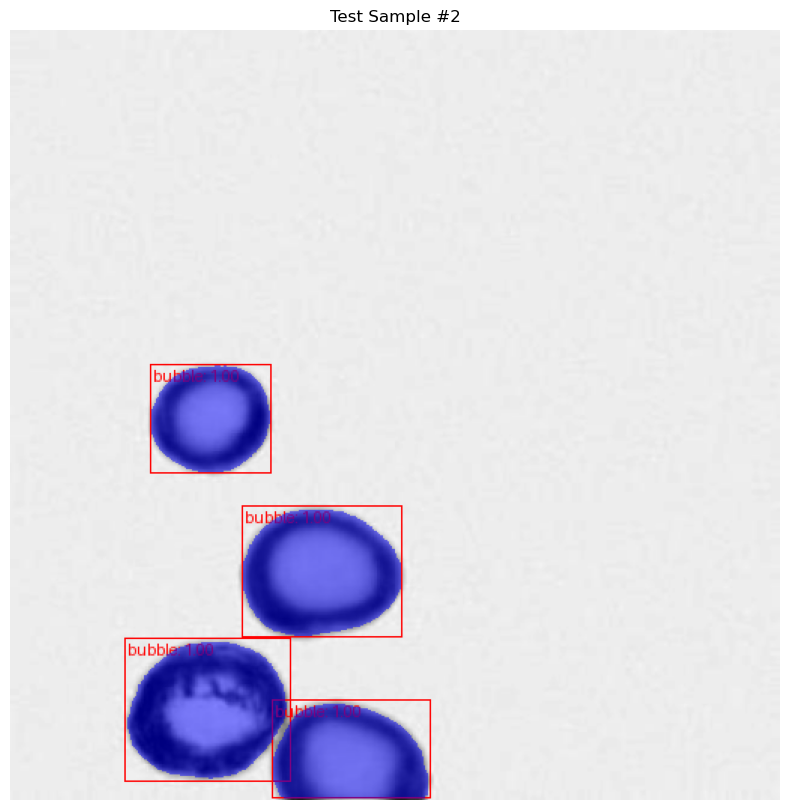

Image 3
Precision: 0.9453187391365622
Recall: 0.992943846837067
F1: 0.9685461940172791
Intersection: 20123
Union: 21430
Dice: 0.9685461939939705
Drawing predictions...


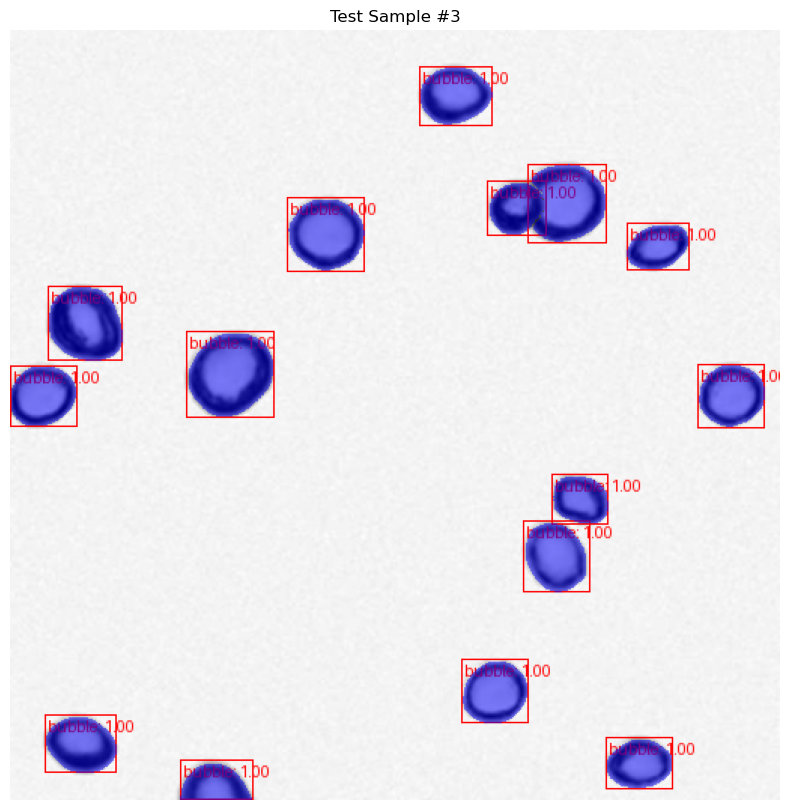

Image 4
Precision: 0.7093620629457829
Recall: 0.9749108856594462
F1: 0.8212027600542772
Intersection: 14222
Union: 20415
Dice: 0.8212027600305684
Drawing predictions...


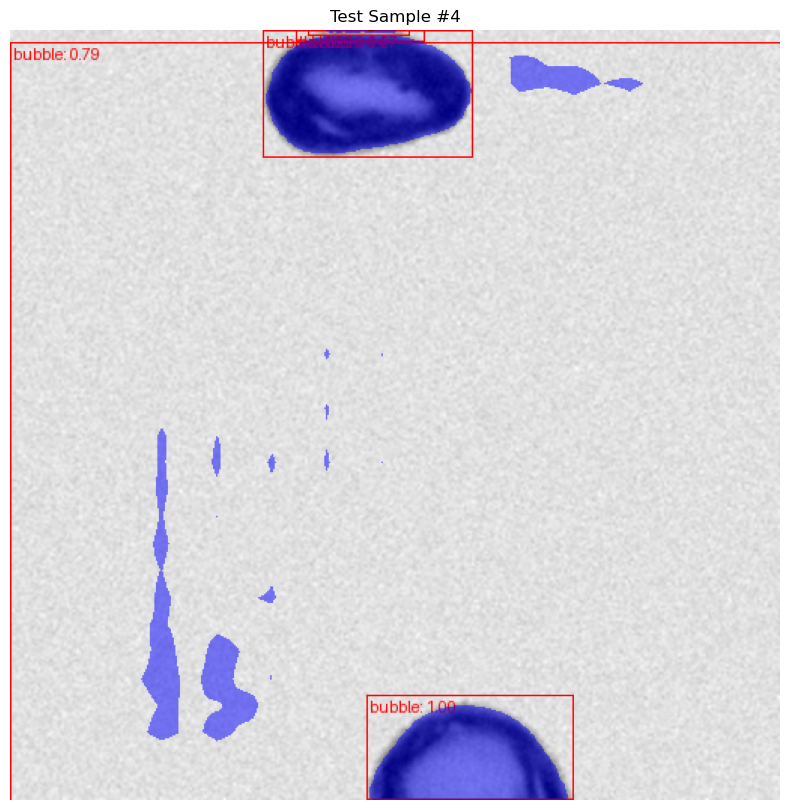

Image 5
Precision: 0.7369683957945253
Recall: 0.9868098418872072
F1: 0.8437833245973937
Intersection: 23342
Union: 31985
Dice: 0.8437833245821428
Drawing predictions...


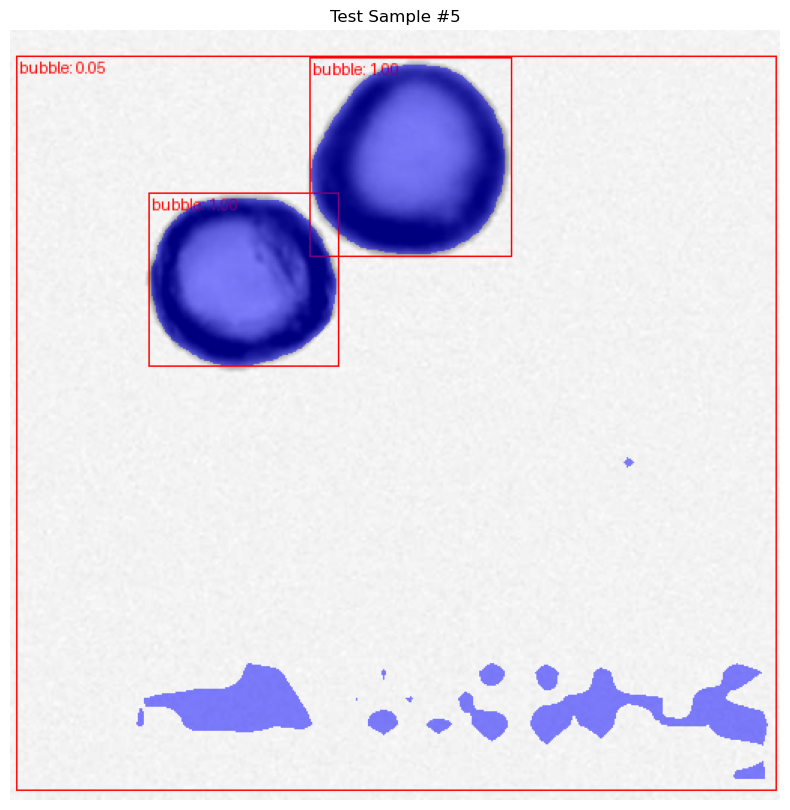

Image 6
Precision: 0.9996123697131536
Recall: 0.8721909056745585
F1: 0.9315645821626395
Intersection: 23209
Union: 26619
Dice: 0.9315645821439439
Drawing predictions...


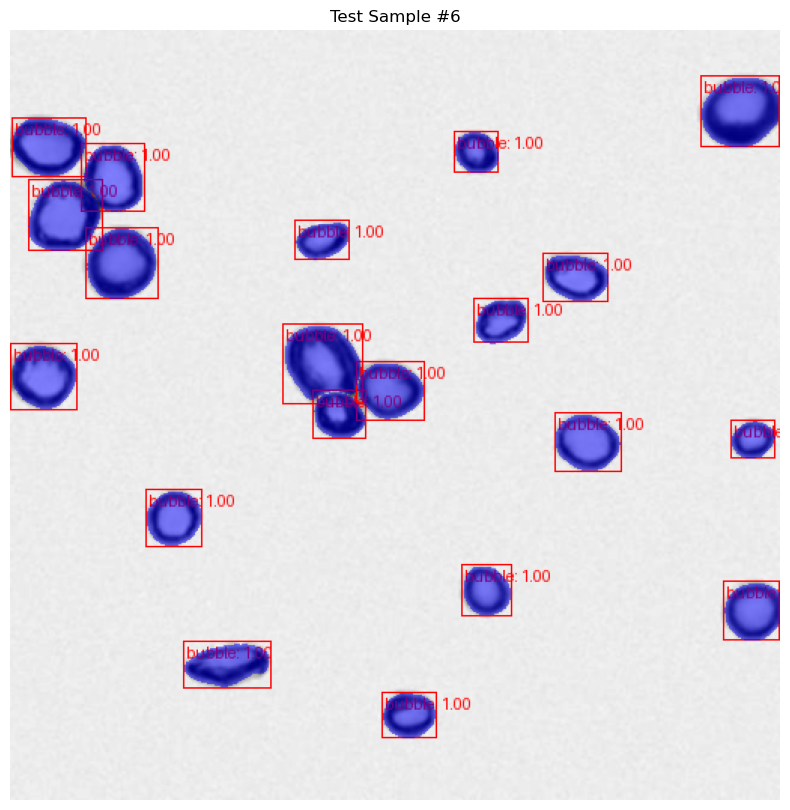

Image 7
Precision: 0.9962008847254749
Recall: 0.9143102789453573
F1: 0.9535005354785684
Intersection: 19142
Union: 21009
Dice: 0.9535005354548205
Drawing predictions...


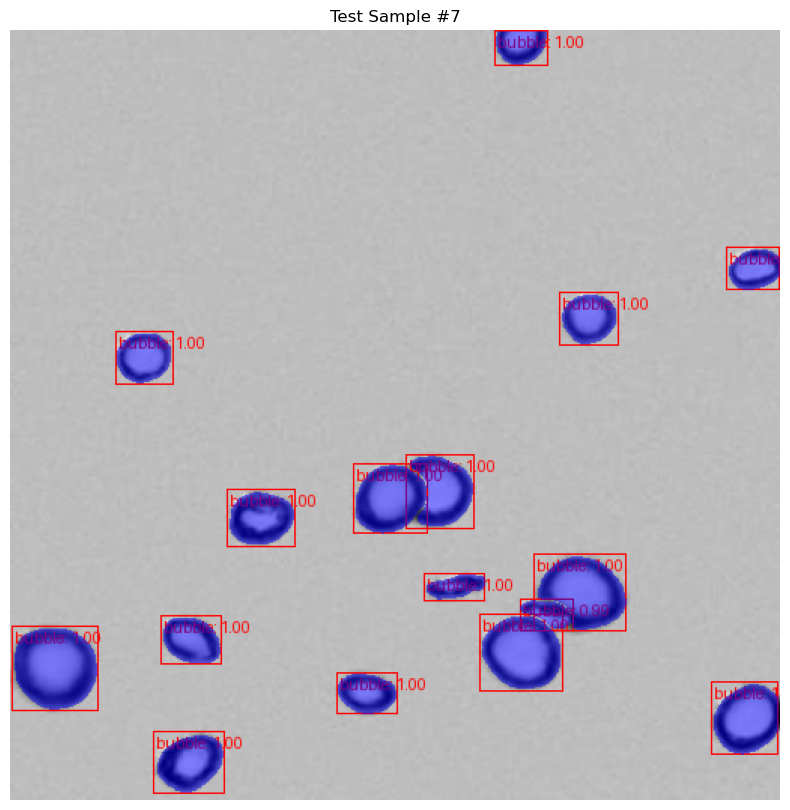

Image 8
Precision: 0.9753772100342497
Recall: 0.9863334269399981
F1: 0.9808247230754911
Intersection: 21074
Union: 21898
Dice: 0.9808247230526663
Drawing predictions...


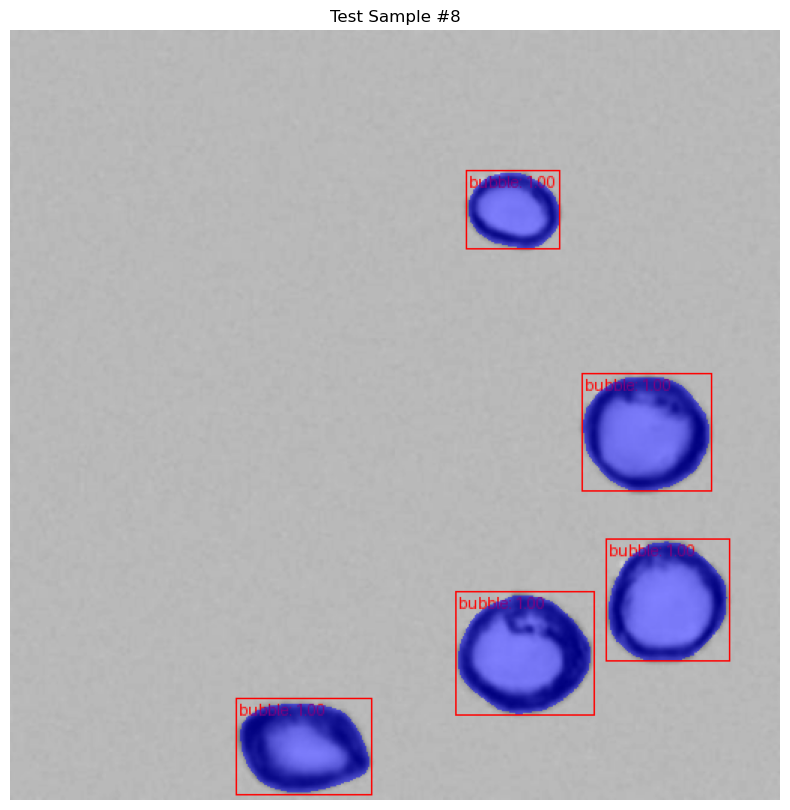

Image 9
Precision: 0.9663411886207868
Recall: 0.9774918087278598
F1: 0.9718845164184037
Intersection: 20585
Union: 21776
Dice: 0.9718845163954608
Drawing predictions...


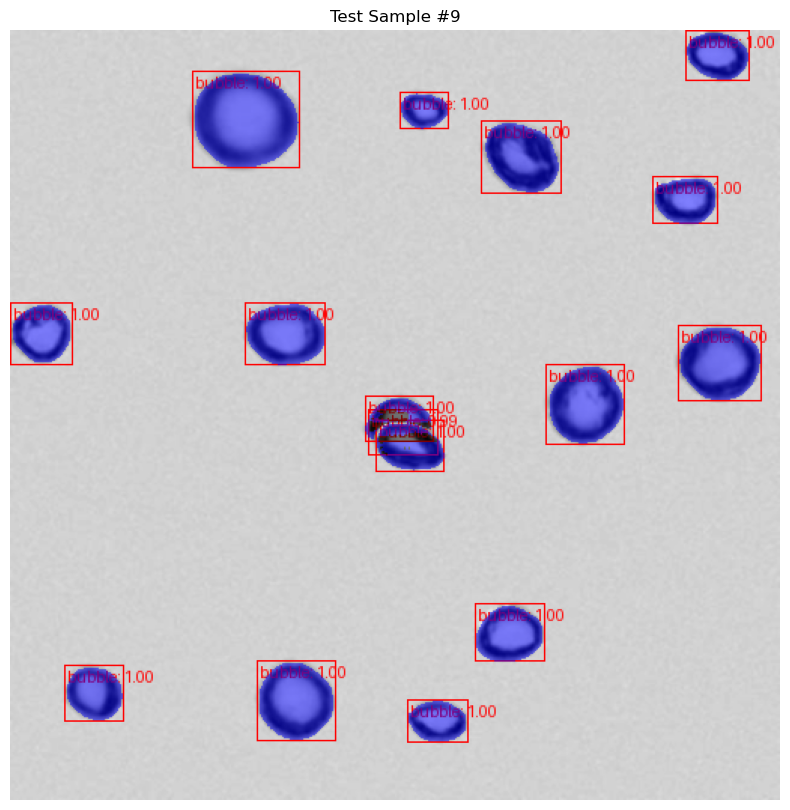

Image 10
Average Precision: 0.92931328723582
Average Recall: 0.9500168947531336
Average F1-score: 0.9346156803268322
Average Dice Coefficient: 0.9346156803030572


In [11]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as F
import torch

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

model.eval()

# Number of test images to visualize
N = 10

with torch.no_grad():

    dice_scores = []
    precisions = []
    recalls = []
    f1_scores = []

    for idx, (image, target) in enumerate(data_loader_test):

        print(f"Image {idx}")

        if idx >= N:
            break

        x = image[0].to(device)  # batch size = 1
        x = x[:3, ...]  # Remove alpha channel if present

        pred = model([x])[0]

        pred_masks = (pred["masks"].cpu() > 0.7).squeeze(1).numpy()
        true_masks = target[0]["masks"].cpu().numpy()

        # Combine all masks into one binary mask (union of all instances)
        pred_mask = np.any(pred_masks, axis=0).astype(np.uint8)
        true_mask = np.any(true_masks, axis=0).astype(np.uint8)

        # Flatten for sklearn metrics
        pred_flat = pred_mask.flatten()
        true_flat = true_mask.flatten()

        # Skip empty ground truth
        if true_flat.sum() == 0:
            continue

        precision = precision_score(true_flat, pred_flat, zero_division=0)
        recall = recall_score(true_flat, pred_flat, zero_division=0)
        f1 = f1_score(true_flat, pred_flat, zero_division=0)
        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = np.logical_or(pred_mask, true_mask).sum()
        dice = (2 * intersection) / (pred_mask.sum() + true_mask.sum() + 1e-6)

        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1: {f1}")
        print(f"Intersection: {intersection}")
        print(f"Union: {union}")
        print(f"Dice: {dice}")

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        dice_scores.append(dice)


        
        # Rescale image for visualization
        x_cpu = x.cpu()
        vis_img = (255.0 * (x_cpu - x_cpu.min()) / (x_cpu.max() - x_cpu.min())).to(torch.uint8)

        pred_labels = [f"bubble: {score:.2f}" for score in pred["scores"]]
        pred_boxes = pred["boxes"].cpu().long()
        masks = (pred["masks"].cpu() > 0.7).squeeze(1)

        print(f"Drawing predictions...")

        output_image = draw_bounding_boxes(vis_img, pred_boxes, pred_labels, colors="red")
        output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

        # Plot
        plt.figure(figsize=(10, 10))
        plt.imshow(output_image.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Test Sample #{idx}")
        plt.show()
        
        
    
    print("Average Precision:", np.mean(precisions))
    print("Average Recall:", np.mean(recalls))
    print("Average F1-score:", np.mean(f1_scores))
    print("Average Dice Coefficient:", np.mean(dice_scores))

